# Jornada de IA
## Introdução a Algoritmos de Machine Learning & IA generativa

**Time:** Motiva
**Instrutor:** Rafael Monteiro (rafael.a.monteiro.math@gmail.com)


___ 


# 3. Lab #3 - Detecção de anomalias

In [ ]:
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from IPython.display import Image

IMAGES_PATH = "images"
plt.rc("font", size=14)
plt.rc("axes", labelsize=14, titlesize=14)
plt.rc("legend", fontsize=14)
plt.rc("xtick", labelsize=10)
plt.rc("ytick", labelsize=10)

(100, 2)
(20, 2)


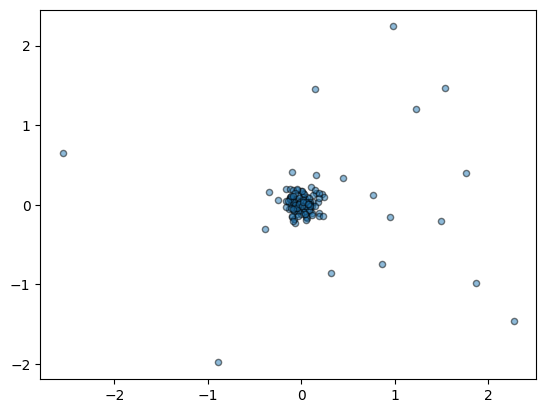

In [ ]:
this_X, y = make_blobs(
    n_samples=100, centers=[(0, 0)], cluster_std=0.1, n_features=2, random_state=0
)
print(this_X.shape)

this_X_, _ = make_blobs(
    n_samples=20, centers=[(0, 0)], cluster_std=1, n_features=2, random_state=0
)
print(this_X_.shape)

this_X = np.concat((this_X, this_X_), axis=0)

plt.scatter(
    this_X[:, 0],
    this_X[:, 1],
    s=20,
    # c=y,
    alpha=0.5,
    edgecolor="k",
    label="Class",
)
# plt.savefig(os.path.join("images", "cluster.png"))
plt.show()

### 3.1.1 Exercício - perfil de inércia

Usando a ideia de inércia que vimos anteriormente no algoritmos Kmeans, faremos o seguinte:

1. gere uma media para a nuvem de pontos dada acima.

```
mean = np.mean(this_X, axis = 0)
```
2. Plote a distancia (ou o quadrado dela) de cada ponto até a média.

```
Dica: a função `np.linalg.norm(X, axis = 1)` pode ser útil aqui
```

3. Plote o perfil de inércia dos pontos. Onde podemos fazer um corte de "anomalia¨?

```
Dica: a função `np.percentile` pode ser útil aqui
```



## 3.2 - Isolation Forests 

Faremos detecção de anomalias utilizando um algoritmo clássico chamado `Isolation Forest` (floresta de isolamento?). A ideia se baseia em definirmos diversas árvores de decisão aleatórias e analisarmos o quão difícil é separarmos (isolarmos) cada ponto de outros. Em poucas palavras, pontos facilmente isoláveis são anômalos; sta ideia é quantificável levando-se em conta o quão profunda se encontra a folha na árvore de decisão que possui somente aquele ponto.

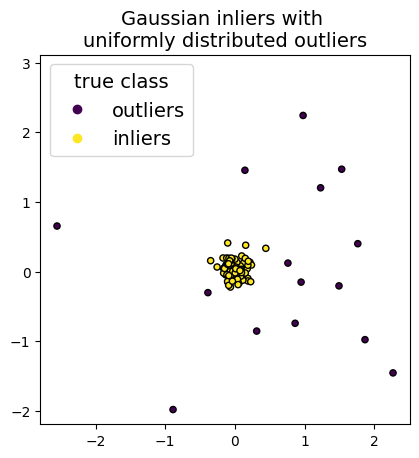

In [ ]:
from sklearn.ensemble import IsolationForest

clf = IsolationForest(random_state=0).fit(this_X)

y_pred = clf.predict(this_X)

scatter = plt.scatter(this_X[:, 0], this_X[:, 1], c=y_pred, s=20, edgecolor="k")
handles, labels = scatter.legend_elements()
plt.axis("square")
plt.legend(handles=handles, labels=["outliers", "inliers"], title="true class")
plt.title("Gaussian inliers with \nuniformly distributed outliers")
plt.show()

### 3.2.1. Exercício

Veja que interessante é a fronteira de decisão deste algoritmo:

In [ ]:
from sklearn.inspection import DecisionBoundaryDisplay

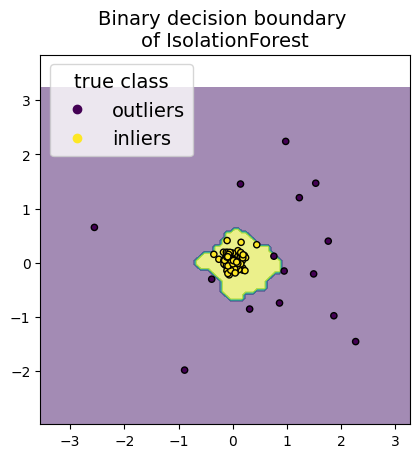

In [ ]:
disp = DecisionBoundaryDisplay.from_estimator(
    clf,
    this_X,
    response_method="predict",
    alpha=0.5,
)
disp.ax_.scatter(this_X[:, 0], this_X[:, 1], c=y_pred, s=20, edgecolor="k")
disp.ax_.set_title("Binary decision boundary \nof IsolationForest")
plt.axis("square")
plt.legend(handles=handles, labels=["outliers", "inliers"], title="true class")
plt.show()

## 3.3. Onde tudo se encontra - classificadores, clusterização etc


Antes de seguirmos adiante, precisamos discutir somente algumas coisinhas quanto a classificadores. 
Em alguns casos eles podem parecer muito bons em determinadas métricas, mas a depender da natureza do conjunto de dados estes números podem não ser assim tão convincentes.


### 3.3.1. MNIST dataset

Existe um conjunto clássico de dados em Machine Learning conhecido como MNIST. Ele é consituído de 70 K dígitos escritos à mão, com anotações de rótulos para todos. Este consjunto de dados foi uma das primeiras ilustrações "grandiosas" de aplicação de algoritmos de machine learning no dia a dia de empresas (no caso, bancos).



In [ ]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784", as_frame=False)

In [ ]:
mnist.keys()  # extra code – we only use data and target in this notebook

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [ ]:
X, y = mnist.data, mnist.target
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784))

Cada dígito está em uma linha dessa matrix. Cada imagem foi "aplainada", perdendo sua estrutura 2D para ser mais facilmente armazenada. Mas elas podem ser facilmente visualizadas, como se vê abaixo. 

In [ ]:
X.shape

(70000, 784)

O número que estamos interessandos em classificar é o número 9.
Ou seja, queremos um  classificador binário que nos diz se o número é um nove ou não.


Nosso interesse no numero 9 se dá especialmente em virtude da similaridade entre este e o número 4 (na grafia de muitas pessoas).

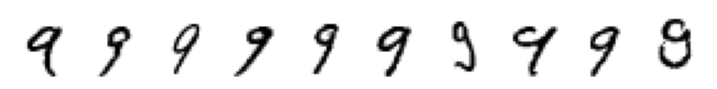

In [ ]:
y_4 = np.where(y == "4")[0]
X_4 = X[y_4][:10]

y_9 = np.where(y == "9")[0]
X_9 = X[y_9][:10]

import matplotlib.pyplot as plt


def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")


# extra code – this cell generates and saves Figure 3–2
plt.figure(figsize=(9, 9))
for idx, image_data in enumerate(X_9):
    plt.subplot(10, 10, idx + 1)
    plot_digit(image_data)
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

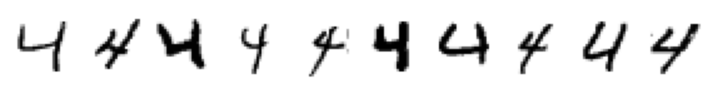

In [ ]:
# extra code – this cell generates and saves Figure 3–2
plt.figure(figsize=(9, 9))
for idx, image_data in enumerate(X_4):
    plt.subplot(10, 10, idx + 1)
    plot_digit(image_data)
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

No caso, vamos utilizar todos os números, buscando distinguir o número 9 dos outros.

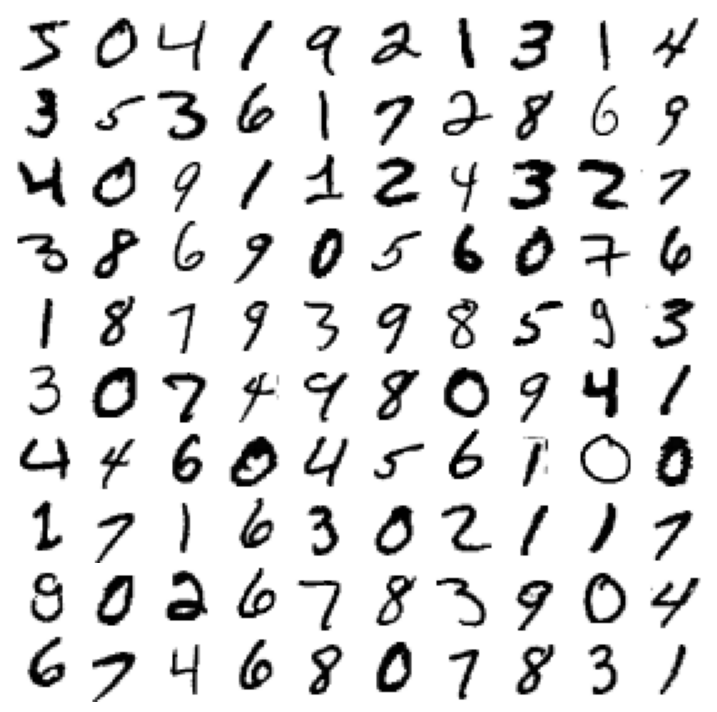

In [ ]:
# extra code – this cell generates and saves Figure 3–2
plt.figure(figsize=(9, 9))
for idx, image_data in enumerate(X[:100]):
    plt.subplot(10, 10, idx + 1)
    plot_digit(image_data)
plt.subplots_adjust(wspace=0, hspace=0)
# save_fig("more_digits_plot", tight_layout=False)
plt.show()

Antes de começarmos, vamos separar o cnjunto de treino do conjunto de testes

In [ ]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [ ]:
y_train_9 = y_train == "9"  # True for all 5s, False for all other digits
y_test_9 = y_test == "9"

## 3.3.2. Otimizando um modelo de classificação

In [ ]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_9)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


### Performance measure



In [ ]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_9, cv=3, scoring="accuracy")

array([0.9456 , 0.95195, 0.9509 ])

Você pode até estar impressionado com estes números. No entanto, se parar para pensar que mais ou menos 90% dos dados é composto de '9's, verá que mesmo um classificador do tipo **_"tudo é não '9'"_** atingiria acurácia próxima a 90%.

Ou seja... 95% não é um número lá tão bom. 

In [ ]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_9)
print(any(dummy_clf.predict(X_train)))

False


In [ ]:
cross_val_score(dummy_clf, X_train, y_train_9, cv=3, scoring="accuracy")

array([0.90085, 0.90085, 0.90085])

Em casos assim, quando o **conjunto de dados é bastante desbalanceado** temos que levar em consideração algumas outras métricas.

### A matriz de confusão


Quais são os tipode de erro que podemos cometer quando fazemos uma classificação binária?
* predizemos como `positiva` uma unidade  que é na verdade `negativa`;
* predizemos como `negativa` uma unidade  que é na verdade `positiva`.

Todos os outros casos são acertos. 

Podemos então representar essa ideia como uma matriz que contrasta previsões com realidade. 
Esta matriz é chamada **"matriz de confusão"**.


**OBS:** abaixo utilizamos o algoritmo [cross_val_predict](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html) para avaliar um classificador. Pesquise sobre como este preditor funciona. Note que a descrição de "conjunto treino" e "conjunto teste" difere da terminologia que utilizamos nos slides (treino e validação, respectivamente).

In [ ]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_9, cv=3)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train_9, y_train_pred)
cm

array([[52715,  1336],
       [ 1695,  4254]])

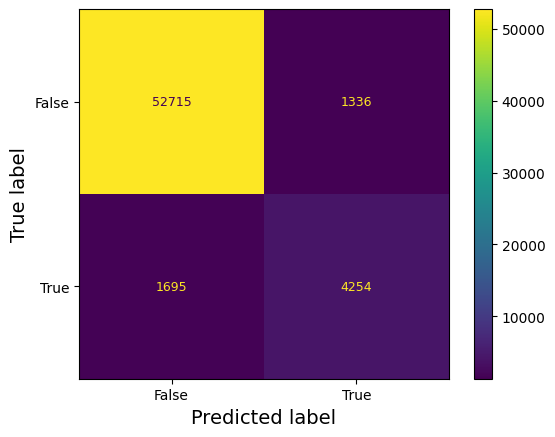

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.rc("font", size=9)
ConfusionMatrixDisplay.from_predictions(y_train_9, y_train_pred)
plt.show()

In [ ]:
y_train_perfect_predictions = y_train_9  # pretend we reached perfection
confusion_matrix(y_train_9, y_train_perfect_predictions)

array([[54051,     0],
       [    0,  5949]])

Oberve que dentre tudo o que o modelo previu como "True" tivemos muitos erros: 1336 eram na verdade "Falso" (não '9's).

Vamos aprender a avaliar essa matriz à seguir.

### Precisão e recall


Tratam-se de dois conceitos muito importantes. 

* **Precisão:** dentre tudo que foi previsto como positivo - True Positives (TP) e False Positives (FP), quantos eram de fato True Positives? É dado pela fórmula $$ \text{Precisão} = \frac{TP}{TP + FP}.$$

* **Recall:** dentre tudo de fato é True Positive (TP), quantos foram de fato apontados pelo algoritmo? É dado pela fórmula $$ \text{Recall} = \frac{TP}{TP + FN}, $$ onde FN é False Negative.




In [ ]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_train_9, y_train_pred)

0.7610017889087657

Ou seja, de cada 10 que o modelo indica como `sendo '9'`, apenas 7.6 o são.

Nada muito extraordinário.

In [ ]:
# extra code – this cell also computes the precision: TP / (FP + TP)
cm[1, 1] / (cm[0, 1] + cm[1, 1])

np.float64(0.7610017889087657)

In [ ]:
recall_score(y_train_9, y_train_pred)  # == 3530 / (1891 + 3530)

0.7150781643973777

In [ ]:
# extra code – this cell also computes the recall: TP / (FN + TP)
cm[1, 1] / (cm[1, 0] + cm[1, 1])

np.float64(0.7150781643973777)

Dado que é muito difícil mantermos dois números em mente e saber qual é o mais importante dentre eles, combinamos os dois em um único indicador chamado como métrica F1, que é o inverso da média hamônica entre eles.

$$ \text{F1 Score} = \frac{2}{\frac{1}{\text{Precisão}} + \frac{1}{\text{Recall}}}.$$

Esta métrica tende a favorecer classificadores que têm Precisão e Recall parecidos.

Deve-se levar em conta o seguinte:
* A depender da natureza do problema com que se trabalha, ter recall ou precisão alta ou baixa pode ser aceitável.
* Por exenplo, em um algoritmo que detecta doenças raras em fetos, o apontamento de uma doença pode suscitar um grande estresse para a gestante. Então, uma acurácia alta é importante. No entanto, se detectar uma doença enquanto no útero é algo que pode levar ao seu tratamento, talvez seja melhor despriorizar precisão e aumentar o recall para que todos os indivíduos que realmente têm a doença sejam apontados pelo algoritmos, mesmo que alguns falsos positivos ocorram.
* O exemplo que o Aurelien Geron dá no livro é o de câmeras de detecção de furtos em shoppings, casos em que precisão baixa é também aceitável, enquanto  recall alto é desejável. 

In [ ]:
from sklearn.metrics import f1_score

f1_score(y_train_9, y_train_pred)

0.737325591472398

### Exercício

Qual a diferença entre acurácia e precisão? Escreva a fórmula para acurácia utilizando os termos FP, FN, TP e TN. 

## 3.3.3. Extra - caso extraordinário de furto de `labels` (aprendizado semi-supervisionado)


(Extraído de Geron, capítulo 8.)

Imaginem vocês que a variável y no conjunto MNIST tenha sido deletada por acidente. O que se pode fazer neste caso?  Reanotarmos todos os dados seria muito custoso e nos tomaria muito tempo.


Há algo que possa ser feito?

Neste exercício vocês serão guiados a uma estratégia para resolver esta questão.



1. Comece por rodar um algoritmo de clusterização K-means  com um número alto de centróides. Algo como 40 ou 50.

In [ ]:
X_train.shape

(60000, 784)

Vamos utilizar somente 2000 itens para treinar o modelo

In [ ]:
k = 50
kmeans = KMeans(n_clusters=k, random_state=42)
X_digits_dist = kmeans.fit_transform(X_train[:2000])

In [ ]:
X_digits_dist.shape

(2000, 50)

Ou seja, cada centroide está nas colunas, nas linhas você tem a distrância daquela unidade até cada uma delas. 

2. O que se pode fazer então é encontrar qual elemento da população é o mais pŕoximo a cada centróide. 

In [ ]:
best_elements_idx = X_digits_dist.argmax(axis=0)

In [ ]:
best_elements_idx

array([1199, 1466, 1999, 1999,  385, 1290, 1999, 1448, 1367, 1420, 1995,
       1397, 1040, 1367, 1999, 1466, 1367, 1397, 1448, 1466, 1397, 1367,
       1873, 1466, 1367,  121,  743, 1040, 1448, 1448,  121, 1290,  121,
        121, 1397, 1290, 1367, 1367, 1466, 1645, 1873, 1367, 1448, 1448,
       1420, 1618, 1466,  121, 1040, 1923])

Este vão ser os elementos que **classificaremos na mão**. 


(Vou ser legal com vocês: vamos assumir que vocês podem obter esses labels do vetor y_train)

In [ ]:
X_representatives = X_train[best_elements_idx]
y_train_representative = y_train[best_elements_idx]

3. Agora vocês farão um processo de **propagação de labels**: vocês farão a predição usando algum algoritmo  para verificar a que cluster cada elemento em X_train pertence. Quando ele pertencer ao cluster 0, ele deverá receber o label dado por y_train_representative. 

In [ ]:
from sklearn.neural_network import MLPClassifier

# Neural network with 1 hidden layer
# hidden_layer_sizes=(100,) means 1 hidden layer with 100 neurons
mlp_clf = MLPClassifier(
    hidden_layer_sizes=(), activation="relu", max_iter=500, random_state=42
)

mlp_clf.fit(X_representatives, y_train_representative)

,hidden_layer_sizes,()
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True
,random_state,42


In [ ]:
from sklearn.metrics import classification_report

y_pred = mlp_clf.predict(X_representatives)
print(classification_report(y_train_representative, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           2       1.00      1.00      1.00         7
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         6
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         6
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         2

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



Humm talvez tenhamos overfit. 


Vamos ver no caso geral

In [ ]:
y_pred = mlp_clf.predict(X_train)

In [ ]:
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.38      0.49      0.43      5923
           1       0.00      0.00      0.00      6742
           2       0.24      0.67      0.36      5958
           3       0.05      0.20      0.08      6131
           4       0.72      0.05      0.10      5842
           5       0.11      0.09      0.10      5421
           6       0.53      0.11      0.19      5918
           7       0.04      0.03      0.04      6265
           8       0.33      0.09      0.14      5851
           9       0.00      0.00      0.00      5949

    accuracy                           0.17     60000
   macro avg       0.24      0.17      0.14     60000
weighted avg       0.24      0.17      0.14     60000



/home/rafael-momo/.pyenv/versions/v310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/rafael-momo/.pyenv/versions/v310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/rafael-momo/.pyenv/versions/v310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

Os números não são assim tão bons, mas podemos tentar melhorá-los de diversas formas:
1. aumentar o tamanho do grupo de treinamento. 
2. Aumentar o número de centroides (embora isso envolva custos) 


## Exercício

Que outras estratégias você imagina para melhorar o processo acima?

